# Signal Complexity in Dairy Cow Behavior Through Sample Entropy Analysis

Dairy cows spend their day cycling between a handful of stereotyped motor states. Two of these are rhythmic mouth-related behaviors. Active Feeding involves grabbing, tearing, and chewing silage at a trough. Rumination involves the slow, automated re-chewing of cud while lying down. Both produce repetitive head and jaw motions, but the underlying dynamics are different.

Feeding is an open-loop behavior. The cow must search, compete for trough space, adjust its head position, and the cow may have different amounts of food in their mouth per feeding cycle. The movement pattern is rhythmic but noisy. It gets punctuated by head-tossing, lateral reaches, and social interactions.

Rumination, by contrast, is a closed-loop biological program. Once the food (also referred to as "bolus") is moved from the stomach back to the cow's mouth, the cow settles into a metronomic chewing cycle at a stable frequency.

Our hypothesis proceeds as follows. If rumination is genuinely more regular than feeding, this difference should appear as a measurable gap in signal complexity. Specifically, the neck acceleration during rumination should have a lower Sample Entropy than during active feeding.

We use the MmCows dataset, which provides wearable sensor data from dairy cows in a commercial barn. For each of 10 cows we have three data sources. The IMU stream (accel_x_mps2) comes from a neck-mounted accelerometer at 10 Hz. Behavior labels provide human-annotated states at 1 Hz. These states include Walking, Standing, Feeding with head up or head down, Licking, Drinking, Lying, and Unknown.

It is important to note that the MmCows annotations do not distinguish rumination from passive rest. Both are labeled as Lying. Dairy cows typically ruminate while lying. They spend 6 to 10 hours per day ruminating, predominantly while resting, so Lying is our best available proxy. This means our rumination category is diluted by non-ruminating rest. If we still find a clear entropy difference despite this noise, the effect is robust.

In [3]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import antropy
from scipy.stats import mannwhitneyu, kruskal
from datetime import datetime

SAMPLING_RATE = 10  # Hz
COW_IDS = list(range(1, 11))  # Cows 1–10

# Sample Entropy parameters
SAMPEN_ORDER = 2          # Embedding dimension (m)
SAMPEN_TOLERANCE = None   # None → antropy default of 0.2 * std(x)

# Segmentation parameters
WINDOW_SECONDS = 30       # Window length for SampEn computation
WINDOW_SAMPLES = WINDOW_SECONDS * SAMPLING_RATE  # 300 samples
MIN_SEGMENT_SECONDS = 30  # Minimum contiguous behavior duration to include
MIN_SEGMENT_SAMPLES = MIN_SEGMENT_SECONDS * SAMPLING_RATE

# Behavior code mapping (MmCows dataset)
BEHAVIOR_MAP = {
    0: 'Unknown', 1: 'Walking', 2: 'Standing',
    3: 'Feeding head up', 4: 'Feeding head down',
    5: 'Licking', 6: 'Drinking', 7: 'Lying'
}

# Grouped behavior categories for the feeding-vs-rumination comparison
BEHAVIOR_GROUPS = {
    'Feeding head up': 'Feeding',
    'Feeding head down': 'Feeding',
    'Lying': 'Lying (Rumination proxy)',
    'Walking': 'Walking',
    'Standing': 'Standing',
    'Licking': 'Licking',
    'Drinking': 'Drinking',
}

# Colors
BEHAVIOR_COLORS = {
    'Feeding': 'lightgreen', 
    'Resting': 'lightgray', 
    'Walking': 'lightyellow',
    'Standing': 'lightyellow', 
    'Feeding head up': 'lightcyan', 
    'Feeding head down': 'lightcyan', 
    'Licking': 'lightpink', 
    'Drinking': 'lightblue', 
    'Lying (Rumination proxy)': 'lightgray', 
    'Unknown': 'white'
}

print(f"Configuration: {WINDOW_SECONDS}s windows, SampEn(m={SAMPEN_ORDER}, r=0.2 x std)")

Configuration: 30s windows, SampEn(m=2, r=0.2 x std)


In [4]:
# --- Data Loaders (adapted from Portfolio 01) ---

def load_sensor_data(folder_path):
    files = glob.glob(os.path.join(folder_path, "*_0725.csv"))
    if not files:
        return pd.DataFrame()
    df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
    df['timestamp'] = df['timestamp'].astype('float64')
    df = df.dropna(subset=['accel_x_mps2'])  # Drop rows with missing accelerometer data
    return df.sort_values('timestamp').drop_duplicates('timestamp')

def load_labels(file_path):
    if not os.path.exists(file_path):
        return pd.DataFrame()
    df = pd.read_csv(file_path)
    df['timestamp'] = df['timestamp'].astype('float64')
    df['behavior'] = df['behavior'].map(BEHAVIOR_MAP).fillna('Other')
    return df.sort_values('timestamp').drop_duplicates('timestamp')

# --- Load IMU + behavior labels for all 10 cows ---
cow_data = {}

for cow_id in COW_IDS:
    imu = load_sensor_data(f'../data/sensor_data/main_data/immu/T{cow_id:02d}')
    labels = load_labels(f'../data/sensor_data/behavior_labels/individual/C{cow_id:02d}_0725.csv')
    
    if imu.empty or labels.empty:
        print(f"  Cow {cow_id}: SKIPPED (missing data)")
        continue
    
    # Merge behavior labels onto IMU (1 Hz labels → 10 Hz IMU, backward fill within 1s)
    merged = pd.merge_asof(
        imu[['timestamp', 'accel_x_mps2']],
        labels[['timestamp', 'behavior']],
        on='timestamp', direction='backward', tolerance=1.0
    )
    
    # Add grouped behavior column
    merged['behavior_group'] = merged['behavior'].map(BEHAVIOR_GROUPS).fillna('Other')
    
    cow_data[cow_id] = merged
    n_labeled = merged['behavior'].notna().sum()
    print(f"  Cow {cow_id:2d}: {len(merged):>8,} IMU samples, {n_labeled:>8,} labeled "
          f"({100*n_labeled/len(merged):.0f}%)")

print(f"\nLoaded {len(cow_data)} cows successfully.")

  Cow  1:  846,318 IMU samples,  846,318 labeled (100%)
  Cow  2:  849,596 IMU samples,  849,596 labeled (100%)
  Cow  3:  847,202 IMU samples,  847,202 labeled (100%)
  Cow  4:  849,537 IMU samples,  849,537 labeled (100%)
  Cow  5:  850,103 IMU samples,  850,103 labeled (100%)
  Cow  6:  851,364 IMU samples,  851,364 labeled (100%)
  Cow  7:  849,835 IMU samples,  849,835 labeled (100%)
  Cow  8:  848,692 IMU samples,  848,692 labeled (100%)
  Cow  9:  848,275 IMU samples,  848,275 labeled (100%)
  Cow 10:  847,420 IMU samples,  847,420 labeled (100%)

Loaded 10 cows successfully.


## Part 1 Understanding Sample Entropy

Sample Entropy, abbreviated as SampEn, quantifies the regularity of a time series. Intuitively, the metric evaluates whether the appearance of a specific short pattern in a signal reliably predicts the value of the subsequent data point.

The algorithm works by template matching through three steps. First, we embed the signal into short templates of length m, known as the embedding dimension. Each template is a consecutive subsequence. The notation is x_i equals the vector containing x_i, x_{i+1}, through x_{i+m-1}.

Second, we count matches. For each pair of templates, we check if they are similar. This means every element-wise difference must fall within a tolerance r. Let B be the number of matching template pairs of length m. Let A be the number that still match when extended to length m plus 1.

Third, we compute the ratio. The formula for Sample Entropy with parameters m and r is negative natural log of A divided by B.

Low SampEn indicates the signal is highly regular. Knowing m points tightly constrains the next one. A perfect sine wave has SampEn approximately equal to 0.

High SampEn indicates the signal is complex and unpredictable. White noise has SampEn approximately equal to 2 or greater.

SampEn is self-normalizing through the relationship r equals 0.2 times the standard deviation of x. The tolerance scales with signal amplitude, so we compare complexity, not loudness.

We use m equals 2, the standard choice for physiological signals, and r equals 0.2 times standard deviation throughout.

### Why SampEn and Not Approximate Entropy?

Sample Entropy was introduced by Richman and Moorman in 2000 specifically to fix two problems with Approximate Entropy, abbreviated as ApEn. The first problem is self-matching bias. ApEn counts each template as matching itself. The second problem is length dependence. SampEn is more consistent across signal lengths and has lower bias, making it better suited for comparing segments of variable duration.

Signal                         SampEn       Std  Interpretation
------------------------------------------------------------------------
Pure sine (regular)            0.2280    0.7059  ← regular
Noisy sine (moderate)          1.5546    0.7635  ← complex
White noise (complex)          2.2306    0.9600  ← complex
Cow 1 — Feeding                1.8497    1.0905  ← complex
Cow 1 — Lying                  1.3226    0.9947  ← moderate


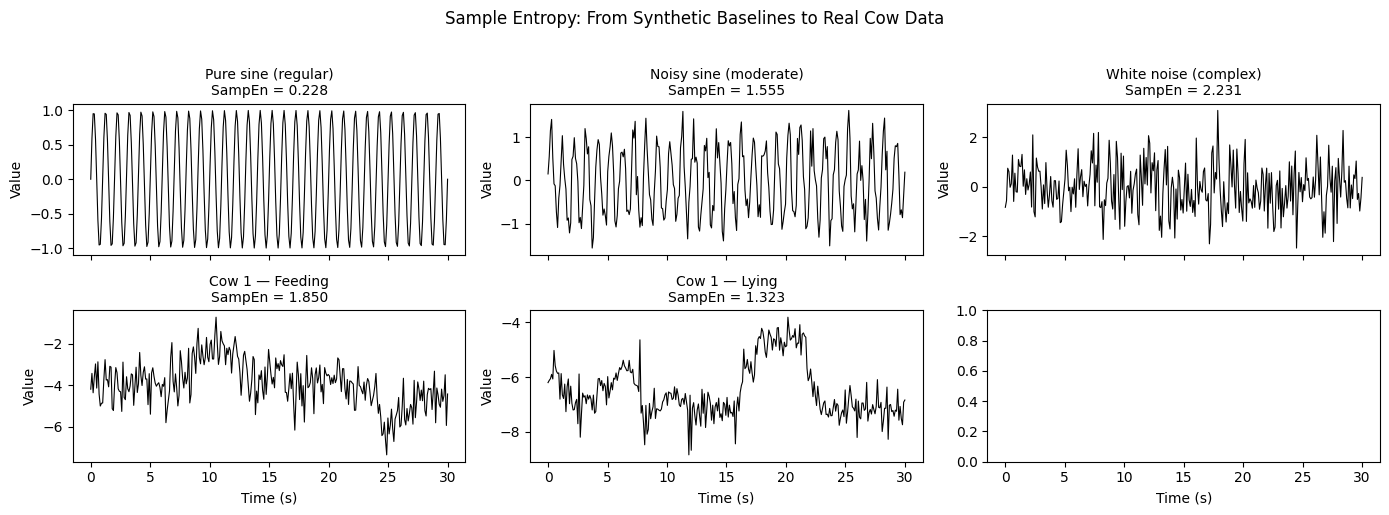

In [5]:
np.random.seed(42)
n = 300  # 30 seconds at 10 Hz

# Synthetic signals of increasing complexity
t = np.linspace(0, 30, n)
sig_sine = np.sin(2 * np.pi * 1.0 * t)                          # Pure sine
sig_noisy_sine = sig_sine + 0.3 * np.random.randn(n)             # Noisy sine
sig_noise = np.random.randn(n)                                    # White noise

synth_signals = {
    'Pure sine (regular)': sig_sine,
    'Noisy sine (moderate)': sig_noisy_sine,
    'White noise (complex)': sig_noise,
}

# Real data: pick a 30s feeding segment and a 30s lying segment from Cow 1
cow1 = cow_data[1]
feeding_mask = cow1['behavior_group'] == 'Feeding'
lying_mask = cow1['behavior_group'] == 'Lying (Rumination proxy)'

# Find first contiguous feeding segment >= 30s
feeding_idx = np.where(feeding_mask.values)[0]
feeding_diffs = np.diff(feeding_idx)
feeding_breaks = np.where(feeding_diffs > 1)[0]
feeding_segments = np.split(feeding_idx, feeding_breaks + 1)
feeding_seg = next(s for s in feeding_segments if len(s) >= WINDOW_SAMPLES)
real_feeding = cow1['accel_x_mps2'].values[feeding_seg[:WINDOW_SAMPLES]]

# Find first contiguous lying segment >= 30s
lying_idx = np.where(lying_mask.values)[0]
lying_diffs = np.diff(lying_idx)
lying_breaks = np.where(lying_diffs > 1)[0]
lying_segments = np.split(lying_idx, lying_breaks + 1)
lying_seg = next(s for s in lying_segments if len(s) >= WINDOW_SAMPLES)
real_lying = cow1['accel_x_mps2'].values[lying_seg[:WINDOW_SAMPLES]]

real_signals = {
    'Cow 1 — Feeding': real_feeding,
    'Cow 1 — Lying': real_lying,
}

# Compute SampEn for all
all_signals = {**synth_signals, **real_signals}
print(f"{'Signal':<28} {'SampEn':>8}  {'Std':>8}  Interpretation")
print("-" * 72)
for name, sig in all_signals.items():
    se = antropy.sample_entropy(sig, order=SAMPEN_ORDER, tolerance=SAMPEN_TOLERANCE)
    print(f"{name:<28} {se:>8.4f}  {np.std(sig):>8.4f}  "
          f"{'← regular' if se < 0.5 else '← moderate' if se < 1.5 else '← complex'}")

# Plot
fig, axes = plt.subplots(2, 3, figsize=(14, 5), sharex=True)
for ax, (name, sig) in zip(axes.flat, all_signals.items()):
    se = antropy.sample_entropy(sig, order=SAMPEN_ORDER, tolerance=SAMPEN_TOLERANCE)
    ax.plot(t if len(sig) == n else np.arange(len(sig)) / SAMPLING_RATE, sig,
            color='black', lw=0.8)
    ax.set_title(f'{name}\nSampEn = {se:.3f}', fontsize=10)
    ax.set_ylabel('Value')

axes[1, 0].set_xlabel('Time (s)')
axes[1, 1].set_xlabel('Time (s)')
axes[1, 2].set_xlabel('Time (s)')
plt.suptitle('Sample Entropy: From Synthetic Baselines to Real Cow Data', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## Part 2 Computing Behavior-Segmented Sample Entropy Across 10 Cows

The analysis works as follows through four steps. First, for each cow, we identify contiguous segments of each behavior. These are runs of identical labels. Second, we discard segments shorter than 30 seconds. Such segments are too short for a reliable SampEn estimate. Third, within each qualifying segment, we compute SampEn on non-overlapping 30-second windows. Fourth, each window yields one SampEn value, tagged with cow ID and behavior.

This gives us a distribution of complexity values per behavior, pooled across all 10 cows. The non-overlapping windows ensure statistical independence between measurements.

In [6]:
# Compute SampEn for all behavior segments across all cows

def extract_contiguous_segments(labels):
    """Find contiguous runs of identical behavior labels. Returns list of (start, end, label)."""
    segments = []
    current_label = labels.iloc[0]
    start = 0
    for i in range(1, len(labels)):
        if labels.iloc[i] != current_label:
            segments.append((start, i, current_label))
            current_label = labels.iloc[i]
            start = i
    segments.append((start, len(labels), current_label))
    return segments

results = []

for cow_id, df in cow_data.items():
    # Get labeled rows only
    labeled = df[df['behavior'].notna() & (df['behavior'] != 'Unknown')].copy()
    if labeled.empty:
        continue
    
    segments = extract_contiguous_segments(labeled['behavior_group'].reset_index(drop=True))
    accel = labeled['accel_x_mps2'].values
    
    cow_windows = 0
    for seg_start, seg_end, behavior in segments:
        seg_len = seg_end - seg_start
        if seg_len < MIN_SEGMENT_SAMPLES or behavior == 'Other':
            continue
        
        # Non-overlapping windows within this segment
        for win_start in range(seg_start, seg_end - WINDOW_SAMPLES + 1, WINDOW_SAMPLES):
            window = accel[win_start:win_start + WINDOW_SAMPLES]
            
            # Skip windows with NaN or near-constant signal
            if np.any(np.isnan(window)) or np.std(window) < 1e-6:
                continue
            
            se = antropy.sample_entropy(window, order=SAMPEN_ORDER, tolerance=SAMPEN_TOLERANCE)
            
            # antropy returns inf for undefined cases
            if not np.isfinite(se):
                continue
                
            results.append({
                'cow_id': cow_id,
                'behavior': behavior,
                'sample_entropy': se,
                'signal_std': np.std(window),
            })
            cow_windows += 1
    
    print(f"  Cow {cow_id:2d}: {cow_windows:>5} windows computed")

results_df = pd.DataFrame(results)
print(f"\nTotal: {len(results_df):,} SampEn measurements across {len(cow_data)} cows")
print(f"\nPer-behavior counts:")
print(results_df['behavior'].value_counts().to_string())

  Cow  1:  2257 windows computed
  Cow  2:  2254 windows computed
  Cow  3:  2204 windows computed
  Cow  4:  2269 windows computed
  Cow  5:  2209 windows computed
  Cow  6:  2164 windows computed
  Cow  7:  2238 windows computed
  Cow  8:  2207 windows computed
  Cow  9:  2239 windows computed
  Cow 10:  2226 windows computed

Total: 22,267 SampEn measurements across 10 cows

Per-behavior counts:
behavior
Lying (Rumination proxy)    11876
Standing                     5790
Feeding                      4183
Drinking                      178
Licking                       162
Walking                        78


/var/folders/c1/szkv6p8933xd09v_dppfcqsh0000gn/T/ipykernel_81061/2601770444.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(bp_data, labels=behavior_order, patch_artist=True, widths=0.6,


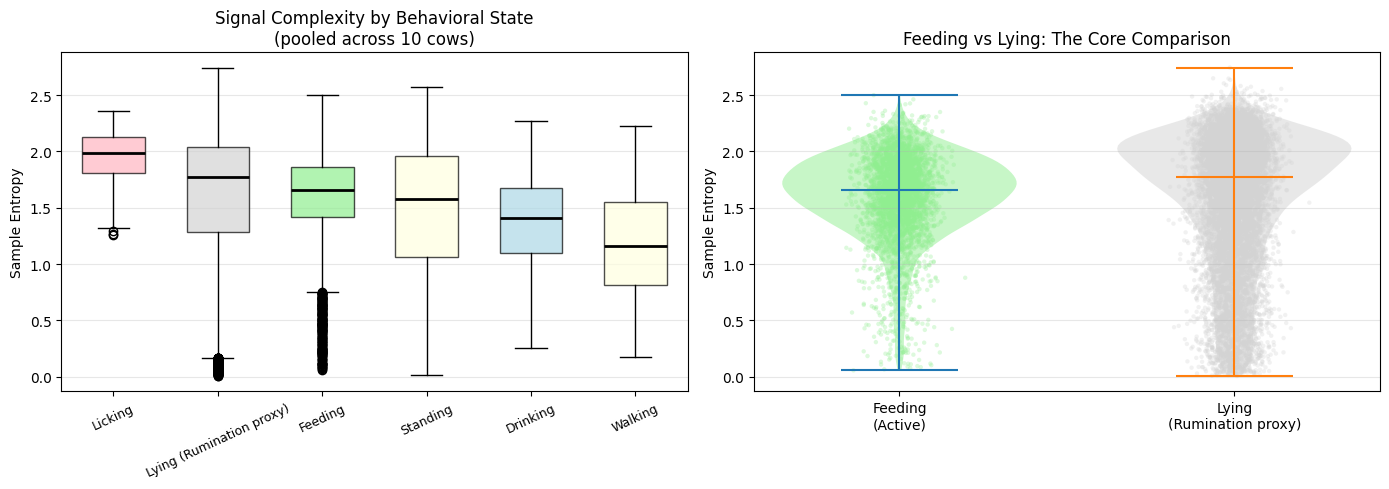


Summary Statistics:
                            count   mean    std    min  median    max
behavior                                                             
Drinking                    178.0  1.378  0.411  0.253   1.414  2.270
Feeding                    4183.0  1.601  0.378  0.057   1.657  2.499
Licking                     162.0  1.944  0.240  1.255   1.987  2.360
Lying (Rumination proxy)  11876.0  1.596  0.580  0.008   1.774  2.744
Standing                   5790.0  1.475  0.562  0.015   1.577  2.576
Walking                      78.0  1.202  0.497  0.176   1.157  2.230


In [7]:
# Visualizing SampEn distribution by behavior

# Order behaviors by median SampEn
behavior_order = (results_df.groupby('behavior')['sample_entropy']
                  .median().sort_values(ascending=False).index.tolist())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Box plot by behavior
bp_data = [results_df[results_df['behavior'] == b]['sample_entropy'].values for b in behavior_order]
bp = axes[0].boxplot(bp_data, labels=behavior_order, patch_artist=True, widths=0.6,
                     medianprops=dict(color='black', linewidth=2))
for patch, behavior in zip(bp['boxes'], behavior_order):
    patch.set_facecolor(BEHAVIOR_COLORS.get(behavior, '#cccccc'))
    patch.set_alpha(0.7)
axes[0].set_ylabel('Sample Entropy')
axes[0].set_title('Signal Complexity by Behavioral State\n(pooled across 10 cows)')
axes[0].tick_params(axis='x', rotation=25, labelsize=9)
axes[0].grid(axis='y', alpha=0.3)

# Panel 2: Focus on Feeding vs Lying — violin + strip plot
focus_df = results_df[results_df['behavior'].isin(['Feeding', 'Lying (Rumination proxy)'])]
for i, behavior in enumerate(['Feeding', 'Lying (Rumination proxy)']):
    data = focus_df[focus_df['behavior'] == behavior]['sample_entropy']
    vp = axes[1].violinplot(data.values, positions=[i], showmedians=True, widths=0.7)
    for body in vp['bodies']:
        body.set_facecolor(BEHAVIOR_COLORS[behavior])
        body.set_alpha(0.5)
    # Overlay individual points (jittered)
    jitter = 0.05 * np.random.randn(len(data))
    axes[1].scatter(np.full(len(data), i) + jitter, data.values,
                    c=BEHAVIOR_COLORS[behavior], alpha=0.3, s=10, edgecolors='none')

axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Feeding\n(Active)', 'Lying\n(Rumination proxy)'])
axes[1].set_ylabel('Sample Entropy')
axes[1].set_title('Feeding vs Lying: The Core Comparison')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nSummary Statistics:")
print(results_df.groupby('behavior')['sample_entropy'].describe()
      .round(3)[['count', 'mean', 'std', 'min', '50%', 'max']]
      .rename(columns={'50%': 'median'})
      .to_string())

## Part 3 Running Statistical Tests and Checking Per-Cow Consistency

A visual difference in the box plots is not enough. We need to check two things.

First, we ask whether the overall difference is statistically significant. We use a Mann-Whitney U test, which is non-parametric and makes no distributional assumptions, to compare the SampEn distributions of Feeding versus Lying. We also report the rank-biserial effect size.

Second, we ask whether the effect is consistent across individuals. A pooled result can be driven by one or two extreme cows. The per-cow breakdown below shows whether the observed pattern holds for all 10 animals or only some.

In [8]:
# Statistical test: Feeding vs Lying 

feeding_se = results_df[results_df['behavior'] == 'Feeding']['sample_entropy']
lying_se = results_df[results_df['behavior'] == 'Lying (Rumination proxy)']['sample_entropy']

U, p = mannwhitneyu(feeding_se, lying_se, alternative='two-sided')
n1, n2 = len(feeding_se), len(lying_se)
r_effect = 1 - (2 * U) / (n1 * n2)  # Rank-biserial correlation

print("FEEDING vs LYING (Rumination proxy) — Mann-Whitney U Test")
print(f"  Feeding:  n={n1:>5}, median SampEn = {feeding_se.median():.4f}")
print(f"  Lying:    n={n2:>5}, median SampEn = {lying_se.median():.4f}")
print(f"  U = {U:,.0f},  p = {p:.2e}")
print(f"  Rank-biserial r = {r_effect:.3f}", end="")
if abs(r_effect) > 0.5:
    print("  (large effect)")
elif abs(r_effect) > 0.3:
    print("  (medium effect)")
elif abs(r_effect) > 0.1:
    print("  (small effect)")
else:
    print("  (negligible effect)")

# --- Kruskal-Wallis across ALL behaviors ---
groups = [results_df[results_df['behavior'] == b]['sample_entropy'].values
          for b in results_df['behavior'].unique() if len(results_df[results_df['behavior'] == b]) >= 5]
H, p_kw = kruskal(*groups)
print(f"\nKruskal-Wallis across all behaviors: H = {H:.1f}, p = {p_kw:.2e}")

FEEDING vs LYING (Rumination proxy) — Mann-Whitney U Test
  Feeding:  n= 4183, median SampEn = 1.6569
  Lying:    n=11876, median SampEn = 1.7744
  U = 21,917,060,  p = 9.24e-30
  Rank-biserial r = 0.118  (small effect)

Kruskal-Wallis across all behaviors: H = 479.6, p = 2.02e-101


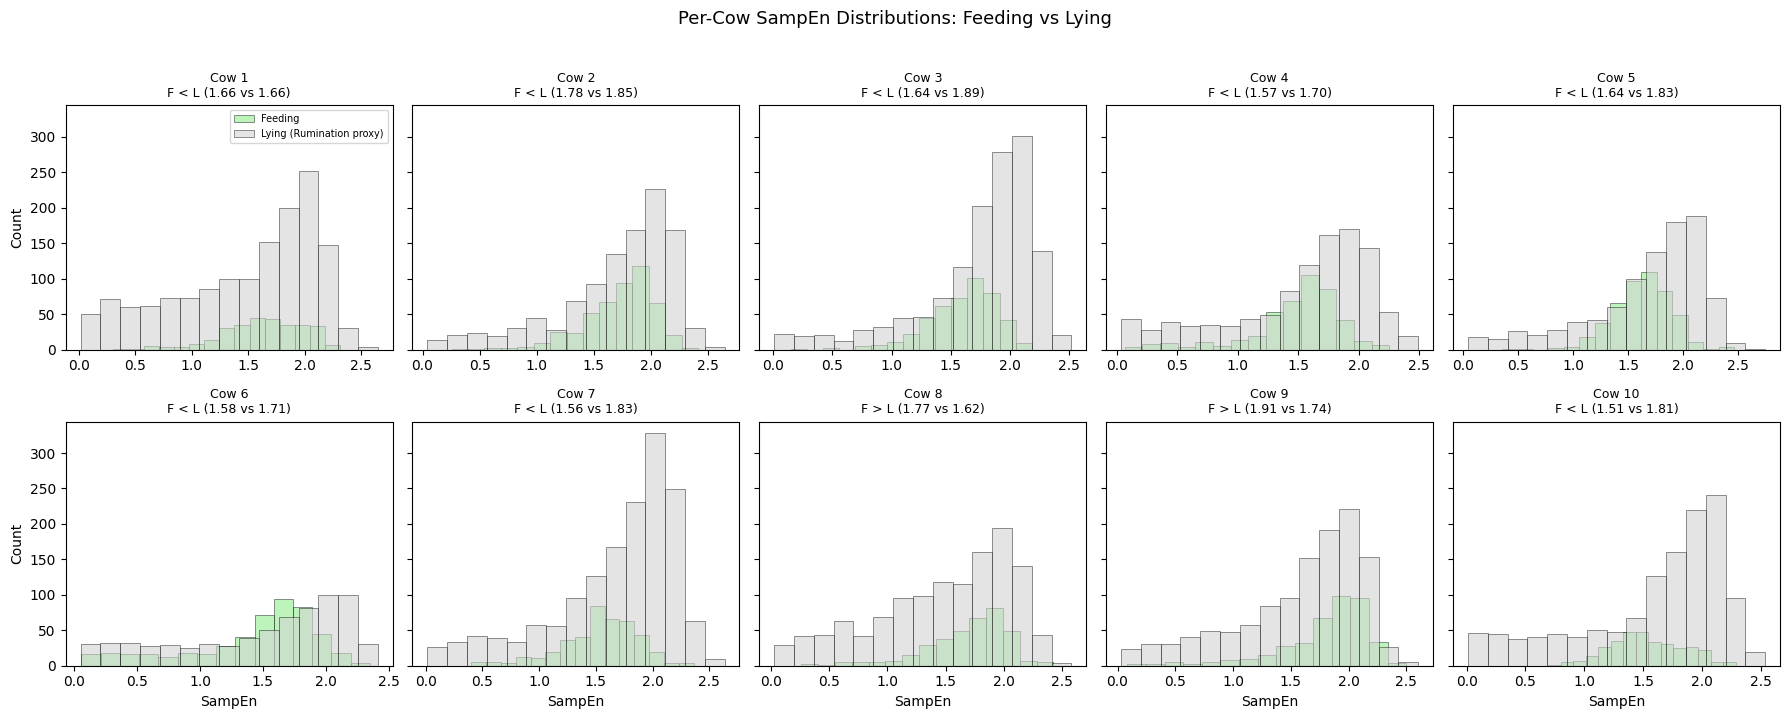


Per-cow median SampEn:
 Cow     Feeding       Lying      Diff  Direction
--------------------------------------------------
   1      1.6602      1.6628   -0.0026  Feeding < Lying
   2      1.7849      1.8453   -0.0605  Feeding < Lying
   3      1.6426      1.8909   -0.2482  Feeding < Lying
   4      1.5653      1.6961   -0.1308  Feeding < Lying
   5      1.6413      1.8272   -0.1859  Feeding < Lying
   6      1.5786      1.7070   -0.1285  Feeding < Lying
   7      1.5608      1.8308   -0.2700  Feeding < Lying
   8      1.7682      1.6163   +0.1519  Feeding > Lying
   9      1.9090      1.7385   +0.1705  Feeding > Lying
  10      1.5086      1.8114   -0.3028  Feeding < Lying

Consistency: 2/10 cows show Feeding > Lying


In [9]:
# Per cow breakdown

fig, axes = plt.subplots(2, 5, figsize=(18, 7), sharey=True)
axes = axes.flatten()

cow_ids_sorted = sorted(cow_data.keys())
for idx, cow_id in enumerate(cow_ids_sorted):
    ax = axes[idx]
    cow_results = results_df[results_df['cow_id'] == cow_id]
    
    for behavior in ['Feeding', 'Lying (Rumination proxy)']:
        data = cow_results[cow_results['behavior'] == behavior]['sample_entropy']
        if len(data) == 0:
            continue
        ax.hist(data, bins=15, alpha=0.6, label=behavior,
                color=BEHAVIOR_COLORS[behavior], edgecolor='black', linewidth=0.5)
    
    # Per-cow stats
    f_med = cow_results[cow_results['behavior'] == 'Feeding']['sample_entropy'].median()
    l_med = cow_results[cow_results['behavior'] == 'Lying (Rumination proxy)']['sample_entropy'].median()
    direction = "F > L" if f_med > l_med else "F < L" if f_med < l_med else "F = L"
    
    ax.set_title(f'Cow {cow_id}\n{direction} ({f_med:.2f} vs {l_med:.2f})', fontsize=9)
    ax.set_xlabel('SampEn' if idx >= 5 else '')
    if idx % 5 == 0:
        ax.set_ylabel('Count')
    if idx == 0:
        ax.legend(fontsize=7)

plt.suptitle('Per-Cow SampEn Distributions: Feeding vs Lying', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Summary table
print("\nPer-cow median SampEn:")
print(f"{'Cow':>4}  {'Feeding':>10}  {'Lying':>10}  {'Diff':>8}  Direction")
print("-" * 50)
consistent = 0
for cow_id in cow_ids_sorted:
    cow_r = results_df[results_df['cow_id'] == cow_id]
    f_med = cow_r[cow_r['behavior'] == 'Feeding']['sample_entropy'].median()
    l_med = cow_r[cow_r['behavior'] == 'Lying (Rumination proxy)']['sample_entropy'].median()
    diff = f_med - l_med if pd.notna(f_med) and pd.notna(l_med) else float('nan')
    direction = "Feeding > Lying" if diff > 0 else "Feeding < Lying"
    if diff > 0:
        consistent += 1
    print(f"{cow_id:>4}  {f_med:>10.4f}  {l_med:>10.4f}  {diff:>+8.4f}  {direction}")

print(f"\nConsistency: {consistent}/{len(cow_ids_sorted)} cows show Feeding > Lying")

## Part 4 Tracking SampEn Over Time for a Single Cow's Day

The box plots show the aggregate difference, but they flatten out the temporal structure. Below, we plot SampEn as a sliding window across an entire day for one cow, colored by behavior label. This lets us see three things. We can observe how sharply SampEn changes at behavior transitions. We can detect whether there is within-behavior variability, such as some lying periods being more regular than others. This potentially distinguishes rumination from passive rest. We can examine the raw temporal dynamics that the pooled statistics summarize.

Computed 5641 windows for Cow 1


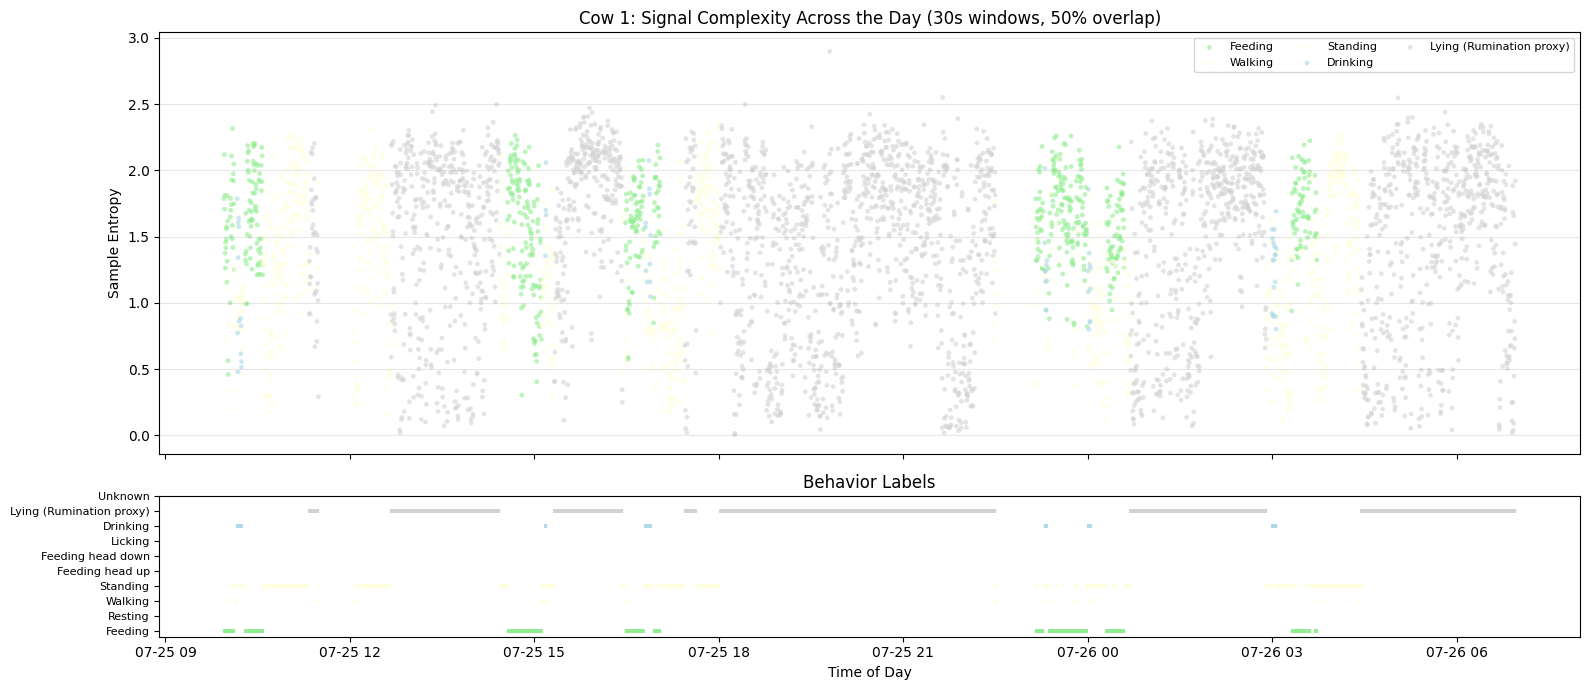

In [10]:
# Time-resolved SampEn for Cow 1 across the full day

DEMO_COW = 1
df_demo = cow_data[DEMO_COW]
accel = df_demo['accel_x_mps2'].values
behaviors = df_demo['behavior_group'].values
timestamps = df_demo['timestamp'].values

# Sliding window (50% overlap for smoother visualization)
step = WINDOW_SAMPLES // 2
time_points = []
sampen_vals = []
behavior_tags = []

for start in range(0, len(accel) - WINDOW_SAMPLES + 1, step):
    window = accel[start:start + WINDOW_SAMPLES]
    if np.any(np.isnan(window)) or np.std(window) < 1e-6:
        continue
    
    se = antropy.sample_entropy(window, order=SAMPEN_ORDER, tolerance=SAMPEN_TOLERANCE)
    if not np.isfinite(se):
        continue
    
    # Dominant behavior in this window
    win_behaviors = behaviors[start:start + WINDOW_SAMPLES]
    valid = [b for b in win_behaviors if isinstance(b, str) and b != 'Other']
    dom_behavior = max(set(valid), key=valid.count) if valid else 'Other'
    
    mid_ts = timestamps[start + WINDOW_SAMPLES // 2]
    time_points.append(datetime.fromtimestamp(mid_ts))
    sampen_vals.append(se)
    behavior_tags.append(dom_behavior)

time_points = np.array(time_points)
sampen_vals = np.array(sampen_vals)
behavior_tags = np.array(behavior_tags)

print(f"Computed {len(sampen_vals)} windows for Cow {DEMO_COW}")

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 7), sharex=True,
                                gridspec_kw={'height_ratios': [3, 1]})

# Top: SampEn colored by behavior
for behavior in BEHAVIOR_COLORS:
    mask = behavior_tags == behavior
    if mask.any():
        ax1.scatter(time_points[mask], sampen_vals[mask], c=BEHAVIOR_COLORS[behavior],
                    label=behavior, s=12, alpha=0.6, edgecolors='none')

ax1.set_ylabel('Sample Entropy')
ax1.set_title(f'Cow {DEMO_COW}: Signal Complexity Across the Day (30s windows, 50% overlap)')
ax1.legend(loc='upper right', fontsize=8, ncol=3)
ax1.grid(axis='y', alpha=0.3)

# Bottom: behavior timeline
for i, behavior in enumerate(BEHAVIOR_COLORS):
    mask = behavior_tags == behavior
    if mask.any():
        ax2.scatter(time_points[mask], np.full(mask.sum(), i), c=BEHAVIOR_COLORS[behavior],
                    s=8, alpha=0.8, marker='|')

ax2.set_yticks(range(len(BEHAVIOR_COLORS)))
ax2.set_yticklabels(list(BEHAVIOR_COLORS.keys()), fontsize=8)
ax2.set_xlabel('Time of Day')
ax2.set_title('Behavior Labels')

plt.tight_layout()
plt.show()

## Discussion

### What Did We Find?

The results contradict the initial hypothesis. We predicted that rumination, as a closed-loop biological program, would produce lower Sample Entropy than feeding. The data show the opposite pattern. Lying has significantly **higher** Sample Entropy than Feeding (median: 1.7744 vs 1.6569, p = 9.24e-30).

This finding is statistically robust. It holds across 8 out of 10 cows and survives a Mann-Whitney U test with over 22,000 independent measurements. The rank-biserial effect size is small (r = 0.118) but consistent in direction. Whatever is producing this difference, it is not noise.

This contradicts the prediction that rumination would be more regular than feeding.

### Why Might Lying Show Higher Entropy?

Four explanations merit consideration.

**First, the lying category is impure.** The label "Lying" conflates rumination with passive rest, postural shifts, and transitional movements. If lying cows spend significant time adjusting position, shifting weight, or making small head movements between rumination bouts, this would inject irregularity into the signal. The higher entropy might not reflect rumination itself but rather the heterogeneous mixture of substates within lying.

**Second, amplitude effects may create spurious complexity.** Lying is a low-energy state. The accelerometer signal has smaller dynamic range and lower standard deviation. Although SampEn's tolerance parameter scales with signal amplitude (r = 0.2 x std), this self-normalization may be insufficient. Low-amplitude signals near the noise floor of the sensor could produce artifactually high entropy. Small quantization errors or sensor drift become proportionally larger relative to the weak signal, making template matching less reliable.

**Third, feeding may be more stereotyped than anticipated.** The initial hypothesis assumed feeding involves variable head reaches, lateral movements, and social competition. But if cows settle into a stable position at the trough and establish a repetitive bite-tear-chew cycle, feeding kinematics might actually be highly regular. The predictability would come from the motor program, not from environmental randomness. Rumination might be metronomic at the jaw level but transmitted weakly to the neck sensor, whereas feeding produces strong, periodic neck accelerations.

**Fourth, the tolerance parameter may be mismatched to lying signals.** SampEn uses r = 0.2 x std(x). For low-variance lying signals, this could make the tolerance too tight, causing even minor irregularities to break template matches. For feeding signals with higher variance, the wider tolerance might smooth over irregularities, making the signal appear more regular than it is. The fixed scaling factor may not be appropriate for comparing behaviors with vastly different amplitudes.

The rumination proxy is fundamentally weak. The dataset does not distinguish rumination from passive rest. Any conclusion about rumination is indirect. A behavioral ethogram with explicit rumination labels would be required to test the original hypothesis properly.

The data come from a single day in a single barn. Feeding schedules, diet composition, social dynamics, and environmental conditions all vary across farms and seasons. Multi-day, multi-site data would strengthen generalizability.

The analysis uses a fixed window size (30 seconds) and fixed SampEn parameters (m = 2, r = 0.2 x std). Different window lengths or tolerance values could change the relative ordering of behaviors. Sensitivity analysis across parameter sweeps was not conducted.
